In [315]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter 
GS_NAVY = "#003B5C"
GS_BLUE = "#0076A8"
GS_MID_BLUE = "#4EA3D8"
GS_LIGHT_BLUE = "#9DD6F5"
GS_PALE_BLUE = "#DCEFF8"
GS_SLATE = "#496B82"
GS_COLORS = [GS_PALE_BLUE, GS_LIGHT_BLUE, GS_MID_BLUE, GS_BLUE, GS_SLATE, GS_NAVY]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.labelcolor": GS_SLATE,
    "xtick.color": GS_SLATE,
    "ytick.color": GS_SLATE,
    "text.color": GS_NAVY,
    "legend.frameon": False,
    "animation.html": "jshtml",
})

## Настройки

In [466]:
DATA_PATH = "/Users/stepansapunkov/HMM_proj/v1/df_v2.parquet"
IMOEX_PATH = "/Users/stepansapunkov/HMM_proj/v1/IMOEX_1h.parquet"

TIMEFRAME = "1h"       # 1h/1d/1w
START = None             #  "2015-01-01"
END = None               # "2024-12-31"
EXPANDING_START = "2018-01-01"
REFIT_RULE = "YS"   
PROBABILITY_OUTPUT_PATH = f"/Users/stepansapunkov/HMM_proj/v1/hmm_forecast_probabilities_{TIMEFRAME}.parquet"
ANIMATION_OUTPUT_PATH = f"/Users/stepansapunkov/HMM_proj/v1/regime_animation_{TIMEFRAME}.mp4"
ANIMATION_FPS = 15

RULES = {"1h": None, "1d": "1D", "1w": "W-FRI"}
WINDOWS = {"1h": 189, "1d": 21, "1w": 10}
MIN_OBS_VALUES = {"1h": 126, "1d": 15, "1w": 6}

FEATURES = ["log_det", "avg_corr", "pc1_share"]
# FEATURES = ["log_det"]

K_VALUES = [2, 3, 4, 5, 6, 7]
K_SELECTED = 4      
RANDOM_STATE = 42
N_ITER = 1000
EIGENVALUE_FLOOR = 1e-10
VAR_LEVEL = 0.95

RULE = RULES[TIMEFRAME]
WINDOW = WINDOWS[TIMEFRAME]
MIN_OBS = MIN_OBS_VALUES[TIMEFRAME]

print(f"TF={TIMEFRAME}, window={WINDOW}, min_obs={MIN_OBS}")
print(f"Features={FEATURES}, selected K={K_SELECTED}")
print(f"Expanding start={EXPANDING_START}, refit={REFIT_RULE}")

TF=1h, window=189, min_obs=126
Features=['log_det', 'avg_corr', 'pc1_share'], selected K=4
Expanding start=2018-01-01, refit=YS


In [436]:
df = pd.read_parquet(DATA_PATH)
im = pd.read_parquet(IMOEX_PATH)

df.index = pd.to_datetime(df.index)
df = df.sort_index()
im["begin"] = pd.to_datetime(im["begin"])
im = im.set_index("begin").sort_index()

if START is not None:
    df = df.loc[START:]
    im = im.loc[START:]
if END is not None:
    df = df.loc[:END]
    im = im.loc[:END]

print("df:", df.shape, df.index.min(), "—", df.index.max())
print("IMOEX:", im.shape, im.index.min(), "—", im.index.max())

df: (45984, 264) 2011-11-17 10:00:00 — 2026-08-29 18:00:00
IMOEX: (36261, 7) 2011-11-17 10:00:00 — 2026-08-28 19:00:00


In [437]:
close = df.filter(regex=r"_close$").copy()
close.columns = close.columns.str.replace("_close", "", regex=False)
close = close.where(close > 0)
imoex_close = im["close"].where(im["close"] > 0)

if RULE is not None:
    close = close.resample(RULE).last().dropna(how="all")
    imoex_close = imoex_close.resample(RULE).last().dropna()

returns = np.log(close).diff()
imoex_returns = np.log(imoex_close).diff()

print("Наблюдений после resample:", len(close))
print("Бумаг:", close.shape[1])

Наблюдений после resample: 45984
Бумаг: 44


In [438]:
dates = []
log_dets = []
avg_corrs = []
pc1_shares = []
n_assets = []

for i in range(WINDOW, len(returns) + 1):
    window_returns = returns.iloc[i - WINDOW:i]

    columns = window_returns.columns[window_returns.notna().sum() >= MIN_OBS]
    corr = window_returns[columns].corr(min_periods=MIN_OBS)

    good = corr.notna().all(axis=0) & corr.notna().all(axis=1)
    corr = corr.loc[good, good]

    if corr.shape[0] < 2:
        continue

    eigenvalues = np.linalg.eigvalsh(corr.to_numpy())
    eigenvalues = np.maximum(eigenvalues, EIGENVALUE_FLOOR)
    upper = corr.to_numpy()[np.triu_indices(len(corr), k=1)]

    dates.append(returns.index[i - 1])
    log_dets.append(np.log(eigenvalues).sum())
    avg_corrs.append(upper.mean())
    pc1_shares.append(eigenvalues[-1] / eigenvalues.sum())
    n_assets.append(len(corr))

features = pd.DataFrame({
    "log_det": log_dets,
    "avg_corr": avg_corrs,
    "pc1_share": pc1_shares,
    "n_assets": n_assets,
}, index=pd.DatetimeIndex(dates, name="date"))

features["imoex_close"] = imoex_close.reindex(features.index)
features["imoex_return"] = imoex_returns.reindex(features.index)


features.tail()

,log_det,avg_corr,pc1_share,n_assets,imoex_close,imoex_return
date,,,,,,
2026-08-29 14:00:00,-63.926663,0.511357,0.538687,42,NaN,NaN
2026-08-29 15:00:00,-64.060195,0.512065,0.539435,42,NaN,NaN
2026-08-29 16:00:00,-64.109502,0.512184,0.539568,42,NaN,NaN
2026-08-29 17:00:00,-64.184687,0.512623,0.539934,42,NaN,NaN
2026-08-29 18:00:00,-64.222091,0.513034,0.540285,42,NaN,NaN


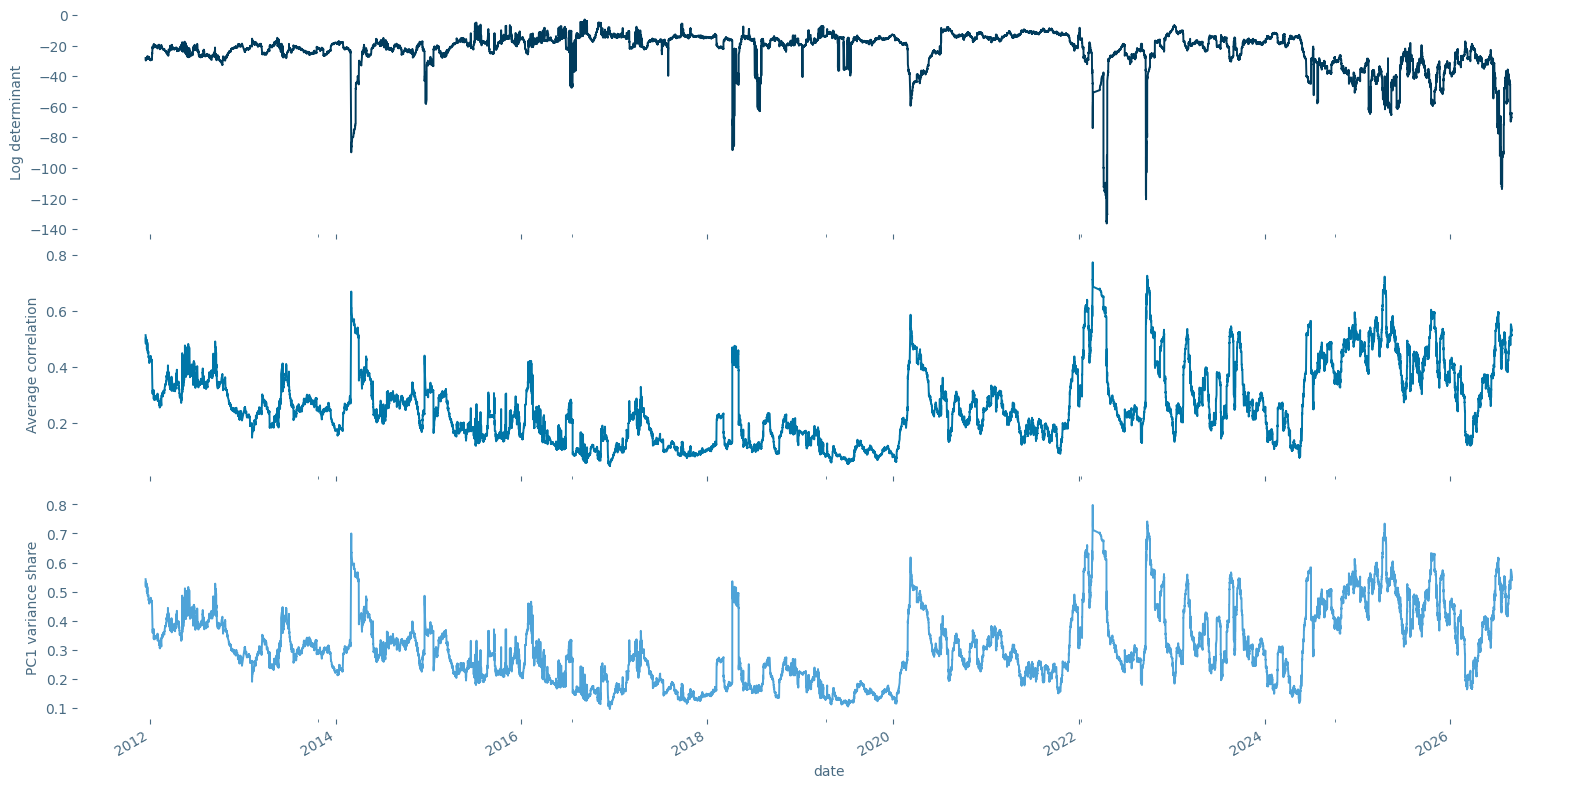

In [439]:
feature_axes = features[["log_det", "avg_corr", "pc1_share"]].plot(
    subplots=True, figsize=(16, 8), sharex=True, linewidth=1.4,
    color=[GS_NAVY, GS_BLUE, GS_MID_BLUE], legend=False,
)
feature_labels = ["Log determinant", "Average correlation", "PC1 variance share"]
for ax, label in zip(feature_axes, feature_labels):
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

In [443]:
hmm_data = features.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES)
selection_data = hmm_data.loc[hmm_data.index < pd.Timestamp(EXPANDING_START)]

if selection_data.empty:
    raise ValueError("No observations before EXPANDING_START.")

feature_mean = selection_data[FEATURES].mean()
feature_std = selection_data[FEATURES].std(ddof=0)

if (feature_std == 0).any():
    raise ValueError("Один из HMM-признаков константный. Измените FEATURES.")

X_selection = ((selection_data[FEATURES] - feature_mean) / feature_std).to_numpy()
models = {}
rows = []

for k in K_VALUES:
    try:
        candidate = GaussianHMM(
            n_components=k,
            covariance_type="full",
            n_iter=N_ITER,
            tol=1e-4,
            random_state=RANDOM_STATE,
        )
        candidate.fit(X_selection)
        models[k] = candidate
        rows.append({
            "K": k,
            "BIC": candidate.bic(X_selection),
            "AIC": candidate.aic(X_selection),
            "log_likelihood": candidate.score(X_selection),
            "converged": candidate.monitor_.converged,
            "iterations": candidate.monitor_.iter,
            "error": "",
        })
    except Exception as error:
        rows.append({
            "K": k, "BIC": np.nan, "AIC": np.nan,
            "log_likelihood": np.nan, "converged": False,
            "iterations": np.nan,
            "error": f"{type(error).__name__}: {error}",
        })

model_selection = pd.DataFrame(rows).set_index("K")
model_selection

,BIC,AIC,log_likelihood,converged,iterations,error
K,,,,,,
2,12488.756528,12329.773951,-6143.886976,True,43,
3,12621.407534,12356.436573,-6143.218286,True,429,
4,-11211.194545,-11597.295088,5849.647544,True,51,
5,-17912.062865,-18434.434189,9286.217094,True,668,
6,-23646.278214,-24320.061515,12249.030758,True,91,
7,-18742.328473,-19582.664950,9902.332475,True,1000,


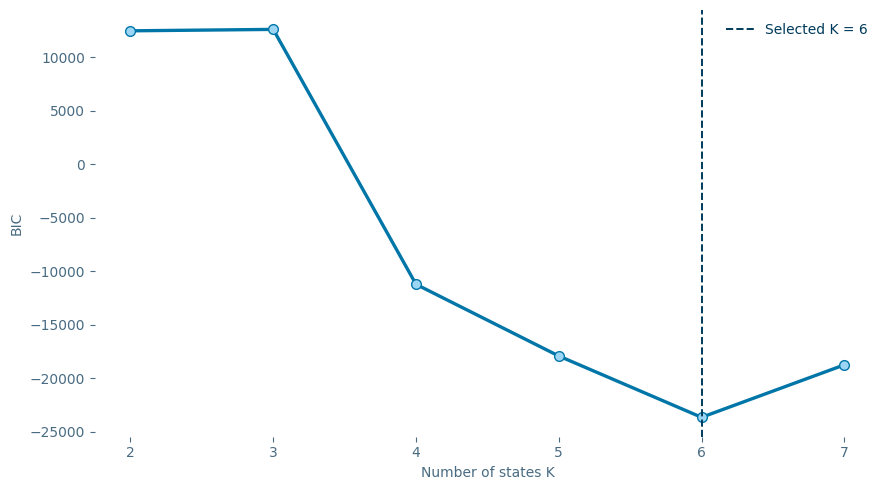

In [447]:
valid_bic = model_selection["BIC"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    valid_bic.index, valid_bic.values, marker="o", linewidth=2.4,
    markersize=7, color=GS_BLUE, markerfacecolor=GS_LIGHT_BLUE,
)
ax.axvline(
    K_SELECTED, color=GS_NAVY, linestyle="--", linewidth=1.4,
    label=f"Selected K = {K_SELECTED}",
)
ax.set_xticks(K_VALUES)
ax.set_xlabel("Number of states K")
ax.set_ylabel("BIC")
ax.legend()
plt.tight_layout()
plt.show()

In [467]:
if K_SELECTED not in models:
    raise ValueError(f"Модель с K={K_SELECTED} не обучилась. Посмотрите таблицу model_selection.")

def filtered_state_probabilities(hmm_model, observations):
    n_observations, n_features = observations.shape
    log_emissions = np.empty((n_observations, K_SELECTED))

    for state in range(K_SELECTED):
        covariance = hmm_model.covars_[state]
        sign, log_determinant = np.linalg.slogdet(covariance)
        if sign <= 0:
            raise ValueError(f"State {state} has a non-positive covariance matrix.")

        difference = observations - hmm_model.means_[state]
        mahalanobis = np.sum(
            difference * np.linalg.solve(covariance, difference.T).T, axis=1
        )
        log_emissions[:, state] = -0.5 * (
            n_features * np.log(2 * np.pi) + log_determinant + mahalanobis
        )

    filtered = np.empty((n_observations, K_SELECTED))
    one_step_ahead = np.empty((n_observations, K_SELECTED))
    state_prior = hmm_model.startprob_.copy()

    for t in range(n_observations):
        log_posterior = np.log(np.maximum(state_prior, 1e-300)) + log_emissions[t]
        log_posterior -= log_posterior.max()
        posterior = np.exp(log_posterior)
        posterior /= posterior.sum()
        filtered[t] = posterior
        state_prior = posterior @ hmm_model.transmat_
        one_step_ahead[t] = state_prior

    return filtered, one_step_ahead


evaluation_data = hmm_data.loc[hmm_data.index >= pd.Timestamp(EXPANDING_START)]
if evaluation_data.empty:
    raise ValueError("No observations on or after EXPANDING_START.")

probability_columns = [f"p_state_{state}" for state in range(K_SELECTED)]
probability_parts = []
decision_time_parts = []
refit_rows = []

for refit_time, segment in evaluation_data.groupby(pd.Grouper(freq=REFIT_RULE)):
    if segment.empty:
        continue

    training_data = hmm_data.loc[hmm_data.index < segment.index.min()]
    expanding_mean = training_data[FEATURES].mean()
    expanding_std = training_data[FEATURES].std(ddof=0)
    if training_data.empty or (expanding_std == 0).any():
        raise ValueError(f"Invalid expanding sample before {segment.index.min()}.")

    combined_data = pd.concat([training_data, segment])
    X_training = ((training_data[FEATURES] - expanding_mean) / expanding_std).to_numpy()
    X_combined = ((combined_data[FEATURES] - expanding_mean) / expanding_std).to_numpy()

    model = GaussianHMM(
        n_components=K_SELECTED, covariance_type="full",
        n_iter=N_ITER, tol=1e-4, random_state=RANDOM_STATE,
    )
    model.fit(X_training)

    raw_filtered, raw_one_step_ahead = filtered_state_probabilities(model, X_combined)
    training_probabilities = raw_filtered[:len(training_data)]
    training_avg_corr = training_data["avg_corr"].to_numpy()
    state_avg_corr = (
        (training_probabilities * training_avg_corr[:, None]).sum(axis=0)
        / training_probabilities.sum(axis=0)
    )
    state_order = np.argsort(state_avg_corr)

    transition = model.transmat_[np.ix_(state_order, state_order)]
    forecast_start = len(training_data) - 1
    forecast_end = forecast_start + len(segment)
    segment_probabilities = raw_one_step_ahead[
        forecast_start:forecast_end, state_order
    ]
    decision_times = combined_data.index[forecast_start:forecast_end]
    probability_parts.append(pd.DataFrame(
        segment_probabilities, index=segment.index, columns=probability_columns
    ))
    decision_time_parts.append(pd.Series(decision_times, index=segment.index))
    latest_filtered_probabilities = raw_filtered[-1, state_order]
    latest_next_probabilities = raw_one_step_ahead[-1, state_order]

    refit_rows.append({
        "refit_time": refit_time,
        "train_end": training_data.index.max(),
        "train_observations": len(training_data),
        "evaluation_observations": len(segment),
        "converged": model.monitor_.converged,
    })

probability_df = pd.concat(probability_parts).sort_index()
probability_df.index.name = "target_time"
forecast_decision_time = pd.concat(decision_time_parts).sort_index()
probability_output = probability_df.copy()
probability_output.insert(0, "decision_time", forecast_decision_time)
probability_output.to_parquet(PROBABILITY_OUTPUT_PATH)
transition_df = pd.DataFrame(
    transition,
    index=[f"state_{state}" for state in range(K_SELECTED)],
    columns=[f"state_{state}" for state in range(K_SELECTED)],
)

result = features.loc[probability_df.index].copy()
result["regime"] = probability_df.to_numpy().argmax(axis=1)
result = result.join(probability_df)

refit_table = pd.DataFrame(refit_rows).set_index("refit_time")
print("Forecast probabilities saved to:", PROBABILITY_OUTPUT_PATH)
refit_table

Forecast probabilities saved to: /Users/stepansapunkov/HMM_proj/v1/hmm_forecast_probabilities_1h.parquet


,train_end,train_observations,evaluation_observations,converged
refit_time,,,,
2018-01-01,2017-12-29 18:00:00,14337,2540,True
2019-01-01,2018-12-29 18:00:00,16877,2520,True
2020-01-01,2019-12-30 18:00:00,19397,3175,True
2021-01-01,2020-12-30 23:00:00,22572,3882,True
2022-01-01,2021-12-30 23:00:00,26454,3010,True
2023-01-01,2022-12-30 23:00:00,29464,3810,True
2024-01-01,2023-12-29 23:00:00,33274,3836,True
2025-01-01,2024-12-30 23:00:00,37110,5158,True
2026-01-01,2025-12-30 23:00:00,42268,3528,True


In [468]:
state_summary = result.groupby("regime").agg(
    observations=("regime", "size"),
    mean_log_det=("log_det", "mean"),
    mean_avg_corr=("avg_corr", "mean"),
    mean_pc1_share=("pc1_share", "mean"),
    mean_imoex_return=("imoex_return", "mean"),
    imoex_volatility=("imoex_return", "std"),
)
state_summary["share"] = state_summary["observations"] / len(result)
state_summary.index = [f"state_{state}" for state in state_summary.index]
state_summary

,observations,mean_log_det,mean_avg_corr,mean_pc1_share,mean_imoex_return,imoex_volatility,share
state_0,5076,-15.397050,0.119514,0.167261,0.000026,0.002693,0.161353
state_1,5498,-17.899747,0.248713,0.296210,0.000031,0.004664,0.174767
state_2,10669,-25.115117,0.293749,0.337423,0.000029,0.003902,0.339140
state_3,10216,-36.270792,0.438511,0.470148,-0.000070,0.009146,0.324740


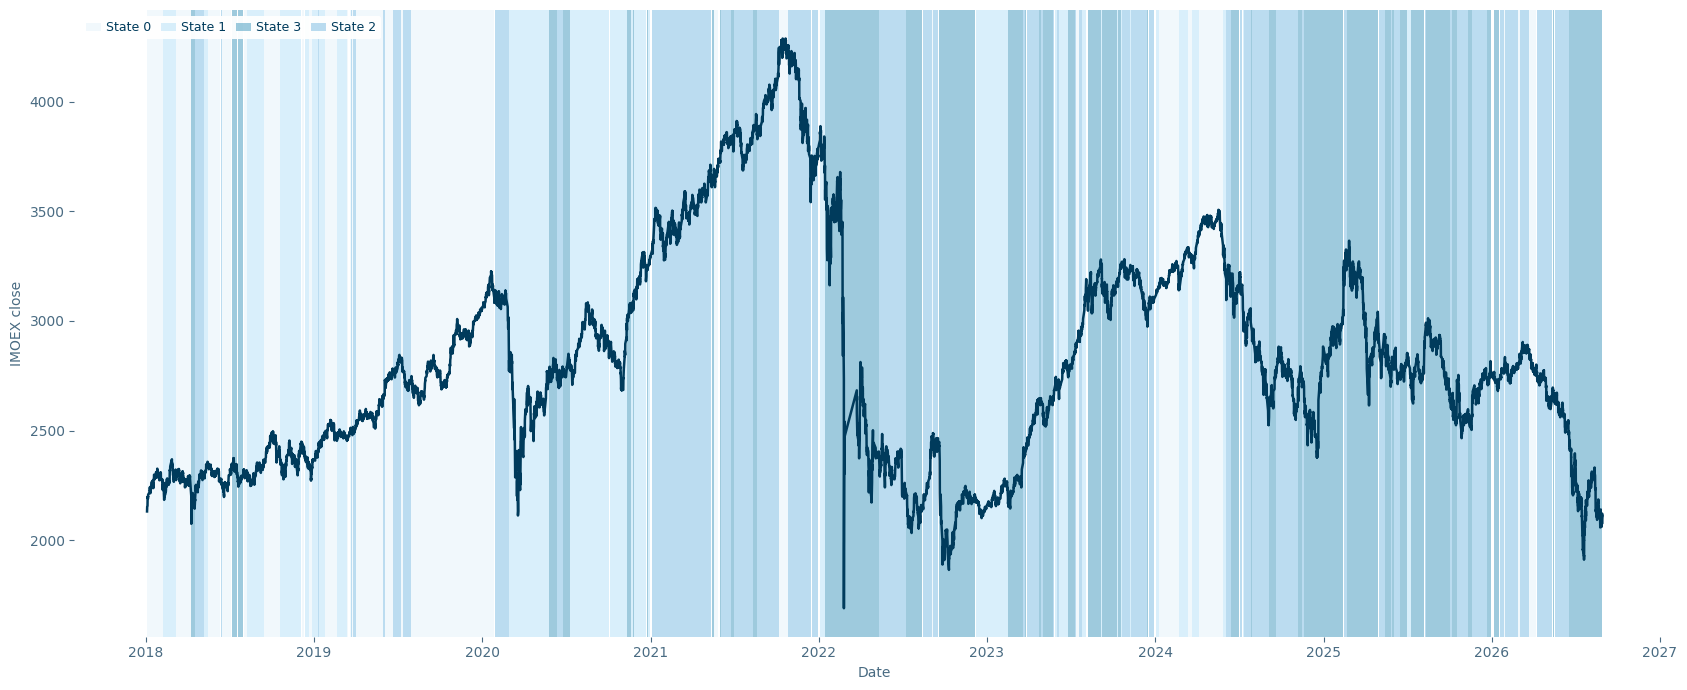

In [469]:
plot_df = result.dropna(subset=["imoex_close"])
colors = np.array(GS_COLORS[:K_SELECTED])
step = plot_df.index.to_series().diff().median()
episode = plot_df["regime"].ne(plot_df["regime"].shift()).cumsum()

fig, ax = plt.subplots(figsize=(17, 7))
states_in_legend = set()
for _, part in plot_df.groupby(episode):
    state = int(part["regime"].iloc[0])
    ax.axvspan(
        part.index[0] - step / 2, part.index[-1] + step / 2,
        color=colors[state], alpha=0.38, linewidth=0,
        label=f"State {state}" if state not in states_in_legend else None,
    )
    states_in_legend.add(state)

ax.plot(plot_df.index, plot_df["imoex_close"], color=GS_NAVY, linewidth=1.8)
ax.set_xlabel("Date")
ax.set_ylabel("IMOEX close")
ax.legend(
    ncol=K_SELECTED, loc="upper left", frameon=True, facecolor="white",
    framealpha=0.95, edgecolor="none", fontsize=9,
    handlelength=1.2, handletextpad=0.4, columnspacing=0.8, borderpad=0.4,
)
plt.tight_layout()
plt.show()

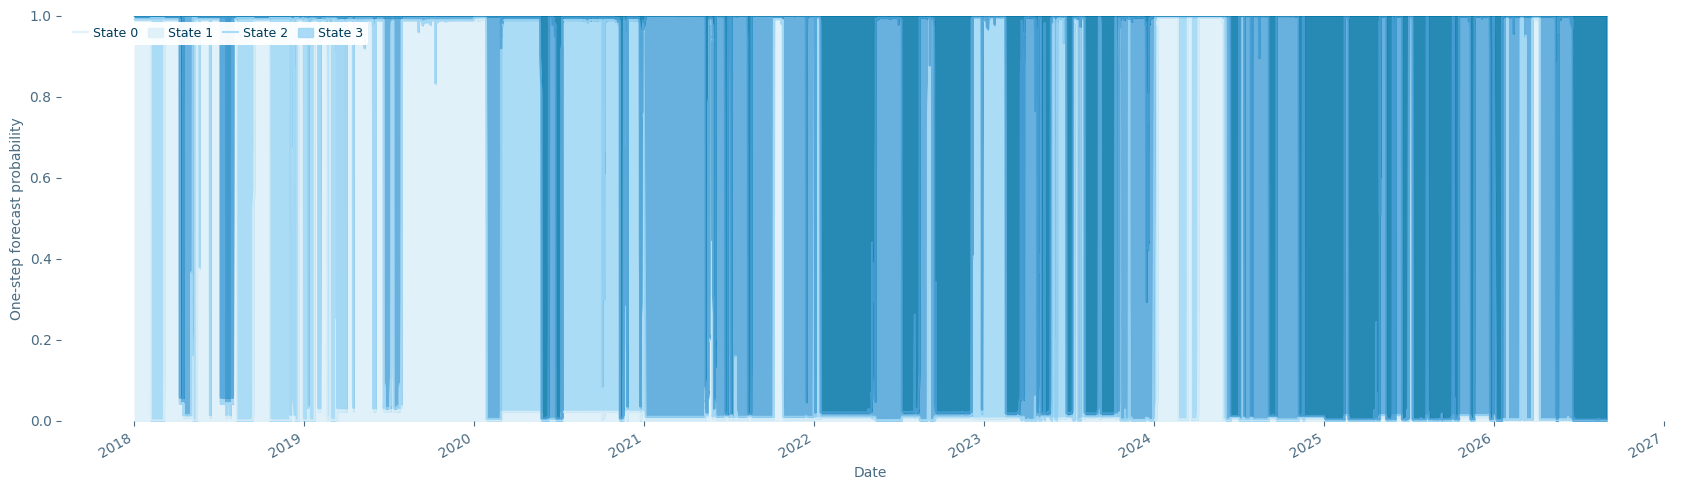

In [470]:
probability_df.plot.area(
    stacked=True, figsize=(17, 5), color=colors, alpha=0.85
)
plt.xlabel("Date")
plt.ylabel("One-step forecast probability")
plt.ylim(0, 1)
plt.legend(
    [f"State {state}" for state in range(K_SELECTED)],
    ncol=K_SELECTED, loc="upper left", frameon=True, facecolor="white",
    framealpha=0.95, edgecolor="none", fontsize=9,
    handlelength=1.2, handletextpad=0.4, columnspacing=0.8, borderpad=0.4,
)
plt.tight_layout()
plt.show()

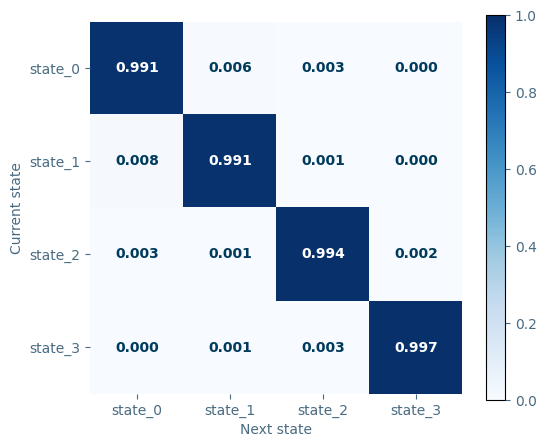

In [471]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(transition_df, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(K_SELECTED), transition_df.columns)
ax.set_yticks(range(K_SELECTED), transition_df.index)

for i in range(K_SELECTED):
    for j in range(K_SELECTED):
        value = transition_df.iloc[i, j]
        ax.text(
            j, i, f"{value:.3f}", ha="center", va="center",
            color="white" if value > 0.50 else GS_NAVY, fontweight="semibold",
        )

ax.set_xlabel("Next state")
ax.set_ylabel("Current state")
fig.colorbar(image, ax=ax)
plt.show()

One-step state forecast uses the full transition matrix: `p(t+1|t) = p(t) × P`. The state with the highest forecast probability is selected for the next period

In [473]:
last_probabilities = latest_filtered_probabilities
next_probabilities = latest_next_probabilities

current_state = int(last_probabilities.argmax())
predicted_next_state = int(next_probabilities.argmax())

next_state_table = pd.DataFrame({
    "probability_at_t": last_probabilities,
    "forecast_probability_t_plus_1": next_probabilities,
}, index=[f"State {state}" for state in range(K_SELECTED)])

print("Most likely current state:", f"State {current_state}")
print("Predicted next state:", f"State {predicted_next_state}")
next_state_table

Most likely current state: State 3
Predicted next state: State 3


,probability_at_t,forecast_probability_t_plus_1
State 0,7.040543e-129,3.635171e-27
State 1,2.591793e-116,5.850627e-04
State 2,1.129412e-24,2.691564e-03
State 3,1.000000e+00,9.967234e-01


In [475]:
tail_probability = 1 - VAR_LEVEL
RISK_WINDOW = max(250, WINDOW * 5)
MIN_RISK_HISTORY = RISK_WINDOW

def weighted_quantile(values, weights, quantile):
    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]
    cumulative_weight = np.cumsum(sorted_weights) / sorted_weights.sum()
    position = min(np.searchsorted(cumulative_weight, quantile), len(sorted_values) - 1)
    return sorted_values[position]

risk_source = result[["imoex_return"] + probability_columns].dropna().copy()
risk_rows = []

for position in range(MIN_RISK_HISTORY, len(risk_source)):
    history_start = position - RISK_WINDOW
    history = risk_source.iloc[history_start:position]
    historical_returns = history["imoex_return"].to_numpy()
    historical_state_probabilities = history[probability_columns].to_numpy()

    forecast_probability = risk_source.iloc[position][probability_columns].to_numpy(dtype=float)

    state_mass = historical_state_probabilities.sum(axis=0)
    available_states = state_mass > 0
    mixture_probability = forecast_probability.copy()
    mixture_probability[~available_states] = 0
    mixture_probability = mixture_probability / mixture_probability.sum()

    mixture_weights = (
        historical_state_probabilities[:, available_states]
        / state_mass[available_states]
    ) @ mixture_probability[available_states]
    mixture_quantile = weighted_quantile(
        historical_returns, mixture_weights, tail_probability
    )
    mixture_tail = historical_returns <= mixture_quantile
    mixture_es = -np.average(
        historical_returns[mixture_tail], weights=mixture_weights[mixture_tail]
    )

    benchmark_weights = np.ones(len(historical_returns), dtype=float)
    benchmark_quantile = weighted_quantile(
        historical_returns, benchmark_weights, tail_probability
    )
    benchmark_tail = historical_returns <= benchmark_quantile
    benchmark_es = -np.average(
        historical_returns[benchmark_tail], weights=benchmark_weights[benchmark_tail]
    )

    target = risk_source.iloc[position]
    target_return = float(target["imoex_return"])
    risk_rows.append({
        "decision_time": forecast_decision_time.loc[risk_source.index[position]],
        "target_time": risk_source.index[position],
        "imoex_return": target["imoex_return"],
        "loss": -target["imoex_return"],
        "regime_var": -mixture_quantile,
        "regime_es": mixture_es,
        "benchmark_var": -benchmark_quantile,
        "benchmark_es": benchmark_es,
        "stress_probability_next": forecast_probability[-1],
        "regime_pit": mixture_weights[historical_returns <= target_return].sum(),
        "benchmark_pit": benchmark_weights[historical_returns <= target_return].sum() / benchmark_weights.sum(),
    })

if not risk_rows:
    raise ValueError("Not enough observations for the selected RISK_WINDOW.")
risk_evaluation = pd.DataFrame(risk_rows).set_index("target_time")
metric_rows = []
for model_name, var_name, es_name, loss_name in [
    ("No regime", "benchmark_var", "benchmark_es", "benchmark_quantile_loss"),
    ("Regime mixture", "regime_var", "regime_es", "regime_quantile_loss"),
]:
    forecast_return_quantile = -risk_evaluation[var_name]
    quantile_error = risk_evaluation["imoex_return"] - forecast_return_quantile
    quantile_loss = np.where(
        quantile_error >= 0,
        tail_probability * quantile_error,
        (tail_probability - 1) * quantile_error,
    )
    risk_evaluation[loss_name] = quantile_loss
    violations = risk_evaluation["loss"] > risk_evaluation[var_name]
    violation_rate = violations.mean()
    realized_tail_loss = risk_evaluation.loc[violations, "loss"].mean()
    predicted_tail_loss = risk_evaluation.loc[violations, es_name].mean()
    metric_rows.append({
        "model": model_name,
        "violation_rate": violation_rate,
        "coverage_error": abs(violation_rate - tail_probability),
        "quantile_loss": float(np.mean(quantile_loss)),
        "es_calibration_error": abs(realized_tail_loss - predicted_tail_loss),
        "mean_var": risk_evaluation[var_name].mean(),
        "mean_es": risk_evaluation[es_name].mean(),
    })

risk_metrics = pd.DataFrame(metric_rows).set_index("model")
risk_metrics

,violation_rate,coverage_error,quantile_loss,es_calibration_error,mean_var,mean_es
model,,,,,,
No regime,0.057247,0.007247,0.000560,0.000648,0.006010,0.010451
Regime mixture,0.051606,0.001606,0.000536,0.000554,0.006445,0.010730


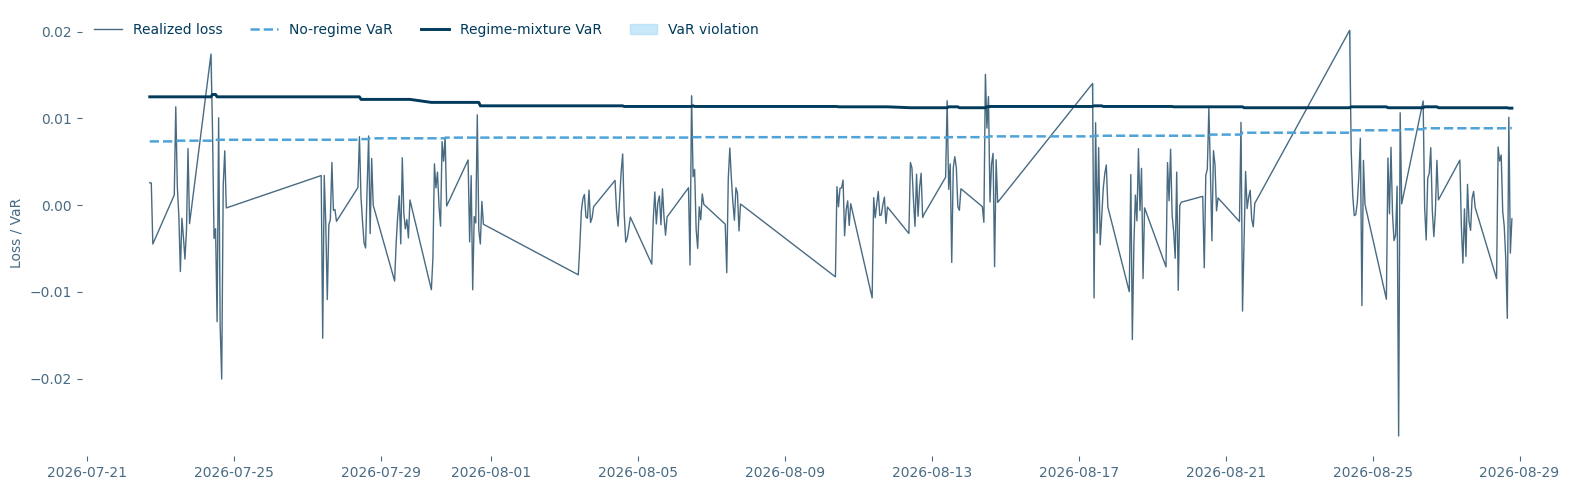

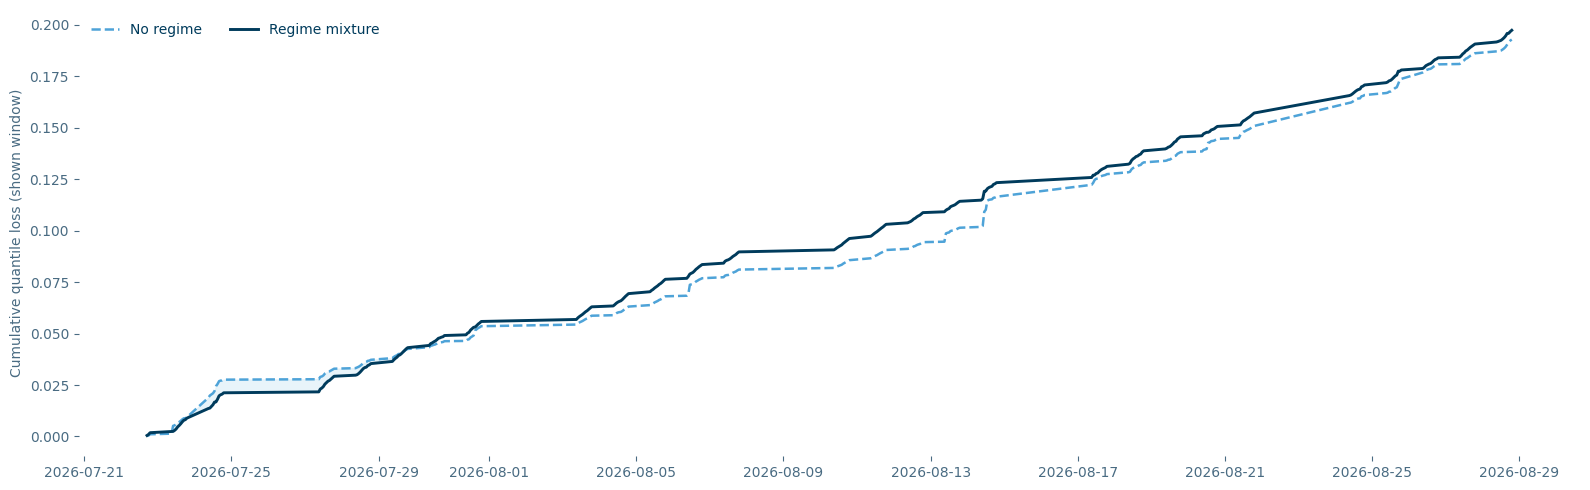

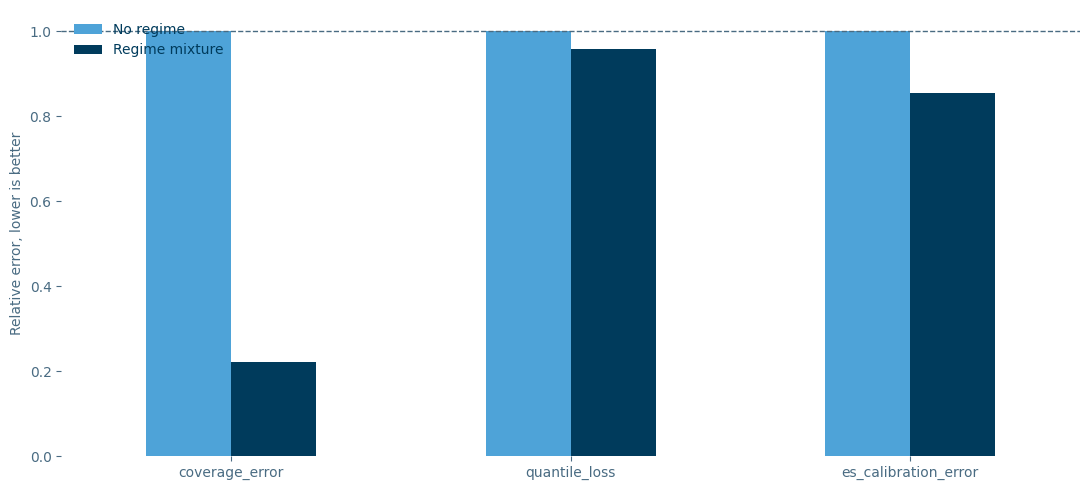

In [476]:
risk_plot = risk_evaluation.tail(min(300, len(risk_evaluation)))

fig, ax_top = plt.subplots(figsize=(16, 5))
ax_top.plot(risk_plot.index, risk_plot["loss"], color=GS_SLATE, linewidth=1.0, label="Realized loss")
ax_top.plot(
    risk_plot.index, risk_plot["benchmark_var"],
    color=GS_MID_BLUE, linewidth=1.8, linestyle="--", label="No-regime VaR",
)
ax_top.plot(
    risk_plot.index, risk_plot["regime_var"],
    color=GS_NAVY, linewidth=2.1, label="Regime-mixture VaR",
)
ax_top.fill_between(
    risk_plot.index, risk_plot["regime_var"], risk_plot["loss"],
    where=risk_plot["loss"] > risk_plot["regime_var"],
    color=GS_LIGHT_BLUE, alpha=0.55, label="VaR violation",
)
ax_top.set_ylabel("Loss / VaR")
ax_top.legend(loc="upper left", ncol=4)
plt.tight_layout()
plt.show()

benchmark_cumulative = risk_plot["benchmark_quantile_loss"].cumsum()
regime_cumulative = risk_plot["regime_quantile_loss"].cumsum()

fig, ax_bottom = plt.subplots(figsize=(16, 5))
ax_bottom.plot(
    risk_plot.index, benchmark_cumulative,
    color=GS_MID_BLUE, linewidth=1.8, linestyle="--", label="No regime",
)
ax_bottom.plot(
    risk_plot.index, regime_cumulative,
    color=GS_NAVY, linewidth=2.1, label="Regime mixture",
)
ax_bottom.fill_between(
    risk_plot.index, regime_cumulative, benchmark_cumulative,
    where=regime_cumulative <= benchmark_cumulative,
    color=GS_PALE_BLUE, alpha=0.65,
)
ax_bottom.set_ylabel("Cumulative quantile loss (shown window)")
ax_bottom.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

comparison_columns = ["coverage_error", "quantile_loss", "es_calibration_error"]
benchmark_metrics = risk_metrics.loc["No regime", comparison_columns].replace(0, np.nan)
relative_metrics = risk_metrics[comparison_columns].div(benchmark_metrics)

ax = relative_metrics.T.plot(
    kind="bar", figsize=(11, 5), color=[GS_MID_BLUE, GS_NAVY], edgecolor="none"
)
ax.axhline(1.0, color=GS_SLATE, linewidth=1.0, linestyle="--")
ax.set_ylabel("Relative error, lower is better")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [477]:
stress_column = f"p_state_{K_SELECTED - 1}"
animation_df = result.dropna(
    subset=["imoex_close", "avg_corr", stress_column]
).copy()

max_animation_points = 1000
if len(animation_df) > max_animation_points:
    animation_df = animation_df.iloc[
        ::int(np.ceil(len(animation_df) / max_animation_points))
    ]

rolling_correlation = animation_df["avg_corr"].rolling(
    max(2, WINDOW // 3),
    min_periods=1
).mean()

correlation_range = rolling_correlation.max() - rolling_correlation.min()

animation_df["correlation_scaled"] = (
    (rolling_correlation - rolling_correlation.min()) / correlation_range
    if correlation_range > 0
    else 0.0
)

animation_figure, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

frame_positions = np.unique(
    np.linspace(
        max(5, len(animation_df) // 100),
        len(animation_df),
        120,
        dtype=int
    )
)

y_min = animation_df["imoex_close"].min()
y_max = animation_df["imoex_close"].max()
x_min = animation_df.index.min()
x_max = animation_df.index.max()
animation_step = animation_df.index.to_series().diff().median()

def update_animation(end_position):
    part = animation_df.iloc[:end_position]

    ax_top.clear()
    ax_bottom.clear()

    animation_episode = (
        part["regime"]
        .ne(part["regime"].shift())
        .cumsum()
    )

    states_in_legend = set()

    for _, regime_part in part.groupby(animation_episode):
        state = int(regime_part["regime"].iloc[0])

        ax_top.axvspan(
            regime_part.index[0] - animation_step / 2,
            regime_part.index[-1] + animation_step / 2,
            color=colors[state],
            alpha=0.38,
            linewidth=0,
            label=f"State {state}" if state not in states_in_legend else None,
        )

        states_in_legend.add(state)

    ax_top.plot(
        part.index,
        part["imoex_close"],
        color=GS_NAVY,
        linewidth=1.8
    )

    ax_top.set_ylabel("IMOEX close")
    ax_top.set_xlim(x_min, x_max)
    ax_top.set_ylim(y_min * 0.98, y_max * 1.02)

    ax_top.legend(
        loc="upper left",
        ncol=K_SELECTED,
        frameon=True,
        facecolor="white",
        framealpha=0.95,
        edgecolor="none",
        fontsize=8,
        handlelength=1.0,
        handletextpad=0.3,
        columnspacing=0.7,
        borderpad=0.35,
    )

    ax_bottom.plot(
        part.index,
        part["correlation_scaled"],
        color=GS_MID_BLUE,
        linewidth=1.8,
        label="Rolling average correlation",
    )

    ax_bottom.plot(
        part.index,
        part[stress_column],
        color=GS_NAVY,
        linewidth=2.0,
        label="Forecast stress probability",
    )

    ax_bottom.fill_between(
        part.index,
        0,
        part[stress_column],
        color=GS_LIGHT_BLUE,
        alpha=0.25,
        linewidth=0,
    )

    ax_bottom.set_xlabel("Date")
    ax_bottom.set_ylabel("Scaled value")
    ax_bottom.set_xlim(x_min, x_max)
    ax_bottom.set_ylim(0, 1)
    ax_bottom.set_yticks([0, 0.5, 1.0])
    ax_bottom.grid(False)
    ax_bottom.tick_params(axis="both", length=0)

    ax_bottom.legend(
        loc="upper left",
        ncol=2,
        frameon=True,
        facecolor="white",
        framealpha=0.95,
        edgecolor="none",
        fontsize=8,
        handlelength=1.0,
        handletextpad=0.3,
        columnspacing=0.7,
        borderpad=0.35,
    )

regime_animation = FuncAnimation(
    animation_figure,
    update_animation,
    frames=frame_positions,
    interval=80,
    repeat=False,
    blit=False,
)

GIF_OUTPUT_PATH = "regime_animation_1h.gif"

regime_animation.save(
    GIF_OUTPUT_PATH,
    writer=PillowWriter(fps=ANIMATION_FPS),
    dpi=120
)

print("GIF animation saved to:", GIF_OUTPUT_PATH)

plt.close(animation_figure)

GIF_OUTPUT_PATH

GIF animation saved to: regime_animation_1h.gif


'regime_animation_1h.gif'

In [478]:
def bernoulli_log_likelihood(successes, total, probability):
    if total == 0:
        return 0.0
    probability = np.clip(probability, 1e-12, 1 - 1e-12)
    return (
        successes * np.log(probability)
        + (total - successes) * np.log(1 - probability)
    )


def var_backtest_diagnostics(losses, var_forecast, expected_rate):
    hits = (losses > var_forecast).astype(int).to_numpy()
    observations = len(hits)
    violations = int(hits.sum())
    violation_rate = violations / observations

    null_ll = bernoulli_log_likelihood(violations, observations, expected_rate)
    fitted_ll = bernoulli_log_likelihood(violations, observations, violation_rate)
    kupiec_lr = max(0.0, 2 * (fitted_ll - null_ll))

    if observations < 2:
        independence_lr = np.nan
    else:
        previous_hit = hits[:-1].astype(bool)
        current_hit = hits[1:].astype(bool)
        n00 = int((~previous_hit & ~current_hit).sum())
        n01 = int((~previous_hit & current_hit).sum())
        n10 = int((previous_hit & ~current_hit).sum())
        n11 = int((previous_hit & current_hit).sum())

        transition_rate = (n01 + n11) / (observations - 1)
        rate_after_no_hit = n01 / (n00 + n01) if n00 + n01 else 0.0
        rate_after_hit = n11 / (n10 + n11) if n10 + n11 else 0.0
        independent_ll = bernoulli_log_likelihood(
            n01 + n11, observations - 1, transition_rate
        )
        markov_ll = (
            bernoulli_log_likelihood(n01, n00 + n01, rate_after_no_hit)
            + bernoulli_log_likelihood(n11, n10 + n11, rate_after_hit)
        )
        independence_lr = max(0.0, 2 * (markov_ll - independent_ll))

    joint_lr = kupiec_lr + independence_lr
    return {
        "observations": observations,
        "violations": violations,
        "expected_violations": observations * expected_rate,
        "violation_rate": violation_rate,
        "kupiec_lr": kupiec_lr,
        "independence_lr": independence_lr,
        "conditional_coverage_lr": joint_lr,
        "coverage_5pct": "Pass" if kupiec_lr < 3.841 else "Reject",
        "independence_5pct": (
            "N/A" if not np.isfinite(independence_lr)
            else "Pass" if independence_lr < 3.841 else "Reject"
        ),
        "joint_5pct": (
            "N/A" if not np.isfinite(joint_lr)
            else "Pass" if joint_lr < 5.991 else "Reject"
        ),
    }


var_diagnostics = pd.DataFrame({
    "No regime": var_backtest_diagnostics(
        risk_evaluation["loss"], risk_evaluation["benchmark_var"], tail_probability
    ),
    "Regime mixture": var_backtest_diagnostics(
        risk_evaluation["loss"], risk_evaluation["regime_var"], tail_probability
    ),
}).T

var_diagnostics

,observations,violations,expected_violations,violation_rate,kupiec_lr,independence_lr,conditional_coverage_lr,coverage_5pct,independence_5pct,joint_5pct
No regime,19145,1096,957.25,0.057247,20.265659,71.194247,91.459906,Reject,Reject,Reject
Regime mixture,19145,988,957.25,0.051606,1.029399,37.455814,38.485213,Pass,Reject,Reject


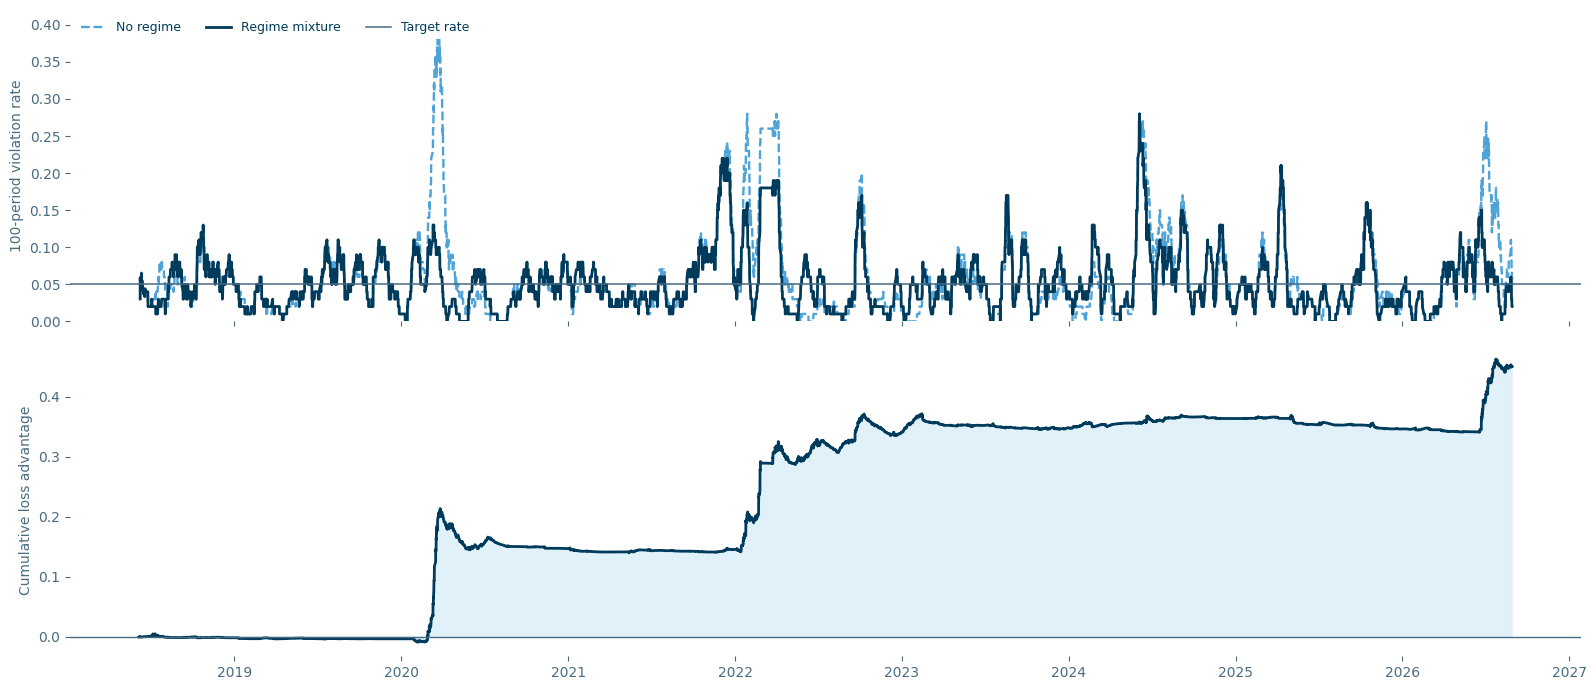

In [479]:
diagnostic_window = min(100, max(20, len(risk_evaluation) // 5))
minimum_points = min(len(risk_evaluation), max(5, diagnostic_window // 3))

rolling_hits = pd.DataFrame({
    "No regime": (risk_evaluation["loss"] > risk_evaluation["benchmark_var"]).astype(float),
    "Regime mixture": (risk_evaluation["loss"] > risk_evaluation["regime_var"]).astype(float),
}).rolling(diagnostic_window, min_periods=minimum_points).mean()

cumulative_advantage = (
    risk_evaluation["benchmark_quantile_loss"]
    - risk_evaluation["regime_quantile_loss"]
).cumsum()

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
ax_top.plot(
    rolling_hits.index, rolling_hits["No regime"],
    color=GS_MID_BLUE, linewidth=1.7, linestyle="--", label="No regime",
)
ax_top.plot(
    rolling_hits.index, rolling_hits["Regime mixture"],
    color=GS_NAVY, linewidth=2.0, label="Regime mixture",
)
ax_top.axhline(tail_probability, color=GS_SLATE, linewidth=1.1, label="Target rate")
ax_top.set_ylabel(f"{diagnostic_window}-period violation rate")
ax_top.set_ylim(bottom=0)
ax_top.legend(
    loc="upper left", ncol=3, frameon=True, facecolor="white",
    framealpha=0.95, edgecolor="none", fontsize=9,
)

ax_bottom.plot(cumulative_advantage.index, cumulative_advantage, color=GS_NAVY, linewidth=2.0)
ax_bottom.axhline(0, color=GS_SLATE, linewidth=1.0)
ax_bottom.fill_between(
    cumulative_advantage.index, 0, cumulative_advantage,
    where=cumulative_advantage >= 0, color=GS_PALE_BLUE, alpha=0.85,
)
ax_bottom.fill_between(
    cumulative_advantage.index, 0, cumulative_advantage,
    where=cumulative_advantage < 0, color=GS_LIGHT_BLUE, alpha=0.35,
)
ax_bottom.set_ylabel("Cumulative loss advantage")
plt.tight_layout()
plt.show()

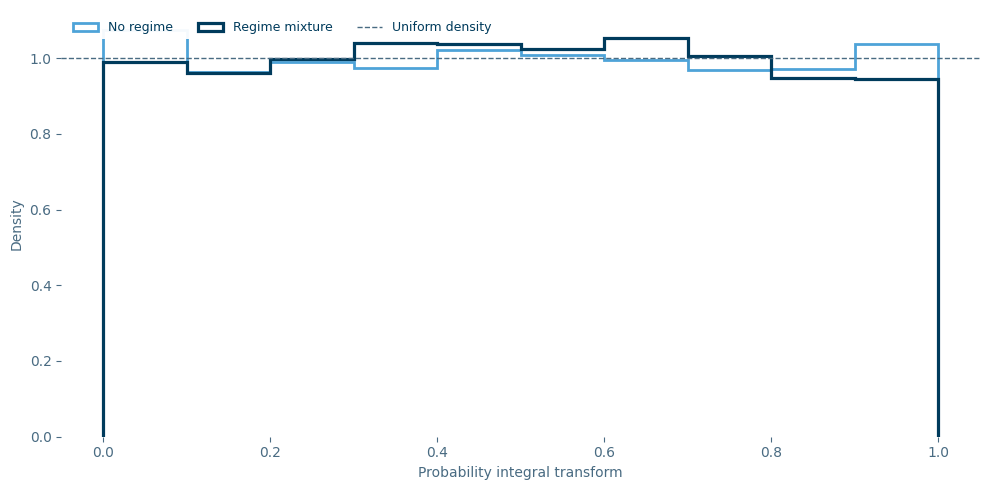

In [480]:
pit_bins = np.linspace(0, 1, 11)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    risk_evaluation["benchmark_pit"], bins=pit_bins, density=True,
    histtype="step", linewidth=2.0, color=GS_MID_BLUE, label="No regime",
)
ax.hist(
    risk_evaluation["regime_pit"], bins=pit_bins, density=True,
    histtype="step", linewidth=2.3, color=GS_NAVY, label="Regime mixture",
)
ax.axhline(1.0, color=GS_SLATE, linewidth=1.0, linestyle="--", label="Uniform density")
ax.set_xlabel("Probability integral transform")
ax.set_ylabel("Density")
ax.legend(
    loc="upper left", ncol=3, frameon=True, facecolor="white",
    framealpha=0.95, edgecolor="none", fontsize=9,
)
plt.tight_layout()
plt.show()